In [9]:
import pandas as pd
import numpy as np
import torch
import torchvision
import PIL
from pathlib import Path


In [10]:
# Setup GPU
# Reference: 
# https://saturncloud.io/blog/how-to-check-if-pytorch-is-using-the-gpu/
# https://saturncloud.io/blog/how-to-train-a-pytorch-model-on-gpu/

device = "cpu"
if  torch.cuda.is_available():
    device = "cuda"

print(device)

cuda


In [11]:
caltechDB = torchvision.datasets.Caltech101("./Databases/CaltechDB/", download=True, target_type="category")


Files already downloaded and verified


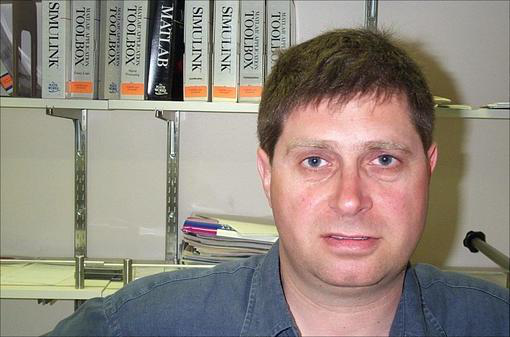

In [12]:
image = caltechDB[0][0]
display(image)

In [56]:
# Reference: https://pytorch.org/vision/stable/models.html

resNetWeight = torchvision.models.ResNet50_Weights.DEFAULT

# pretrained is not supported
resNetModel = torchvision.models.resnet50(progress=True, weights=resNetWeight).to(device)
resNetModel.zero_grad(set_to_none=True)
resNetModel.eval()


# Use the weights to transform the image
imageCopy = image.resize(size=(224,224))
imageTransform = resNetWeight.transforms()(imageCopy).unsqueeze(0).to(device)

# Apply Image and Get the Category
result = resNetModel(imageTransform).squeeze(0).softmax(0).to(device)
# print(prediction.device)
label_index = result.argmax().item()
# print(class_id.device)
confidence = result[label_index].item()
# print(score.device)
label = resNetWeight.meta["categories"][label_index]
# print(category_name.device)
print(label, str(round(confidence*100, 2))+"%")


library 7.83%


In [15]:
# prediction
# class_id
# score
# resNetWeight.meta["categories"]

# So looks like there are 1000 categories if we look at the categories output

In [16]:
# Approach 1: list all categories in order of percentage then chose the one that is avaible in Caltech101
# References: https://pytorch.org/docs/master/generated/torch.topk.html
# 
for i in prediction.topk(10).indices:
    if resNetWeight.meta["categories"][i] in caltechDB.annotation_categories[caltechDB[0][1]]:
        print(i.detach().cpu().numpy(), resNetWeight.meta["categories"][i])
print("Expected: " + str(caltechDB[0][0]))

Expected: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=510x337 at 0x21AFFA7DF10>


In [17]:
resNetWeight.meta["categories"]

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

In [18]:
print("Expected: " + str(caltechDB[0][1]))

# Can't find online how to get the label, so will be using file path
fullName = caltechDB[0][0].filename
imageID = Path(fullName).stem.split("_")[-1]
print(imageID)

Path(fullName)


Expected: 0
0001


WindowsPath('Databases/CaltechDB/caltech101/101_ObjectCategories/Faces/image_0001.jpg')

In [19]:
# Spend some time on Google, and could not find how to get label, so checked with ChatGPT
# and gave the class needed to get the labels
# Proof on chatgpt_9-19-23_getLabel_proof.png

# caltechDB.annotation_categories[caltechDB[0][1]]
caltechDB.annotation_categories

['Faces_2',
 'Faces_3',
 'Leopards',
 'Motorbikes_16',
 'accordion',
 'Airplanes_Side_2',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxopho

In [20]:
# Scrolling through the resnet model, there is no faces
# So Approach 1 does not work, so map labels or modify labels of resnet

In [21]:
# Another Approach is Pretrain the model, but don't want to do it as not 100% if required
# https://www.kaggle.com/code/pmigdal/transfer-learning-with-resnet-50-in-pytorch
# https://github.com/pushkart2/caltech_101_transfer_learning/blob/master/101_object.ipynb
# https://learnopencv.com/image-classification-using-transfer-learning-in-pytorch/

In [46]:
resNetModel = torchvision.models.resnet50(progress=True, weights=resNetWeight)

for parameter in resNetModel.parameters():
    parameter.requires_grad = False

resNetModel.fc = torch.nn.Sequential(
    # Layers as suggested from https://learnopencv.com/image-classification-using-transfer-learning-in-pytorch/
    torch.nn.Linear(resNetModel.fc.in_features, 256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.4),
    torch.nn.Linear(256, 10), 
    torch.nn.LogSoftmax(dim=1) 
).to(device)

0 624 0.07828023284673691


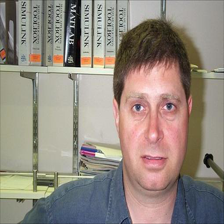

1 453 0.283907026052475


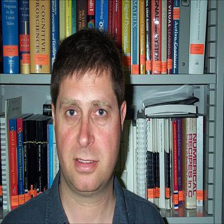

2 0 0.032900724560022354


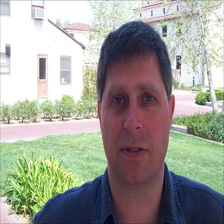

3 917 0.07122231274843216


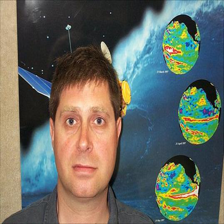

4 743 0.06352698057889938


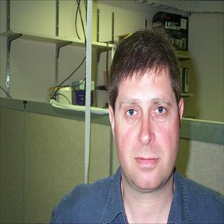

5 624 0.057538051158189774


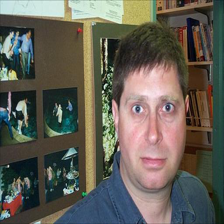

1000 293 0.5108237862586975


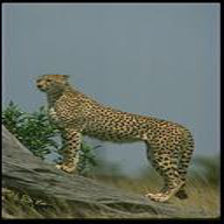

1001 293 0.42044195532798767


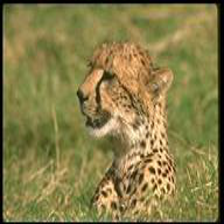

In [63]:
for i in [0,1,2,3,4,5,1000, 1001]:
    imageCopy = caltechDB[i][0].resize(size=(224,224))
    imageTransform = resNetWeight.transforms()(imageCopy).unsqueeze(0).to(device)
    result = resNetModel(imageTransform).squeeze(0).softmax(0).to(device)
    label_index = result.argmax().item()
    confidence = result[label_index].item()
    print(i, label_index, confidence)
    display(imageCopy)